In [24]:
import csv, math
import pandas as pd
from pathlib import Path

path_cat = Path("cat_colonias.sql")
path_edi = Path("edificios_escolares.sql")


In [25]:
def lectura(line: str):
    start = line.find("VALUES")
    if start == -1:
        return None

    blob = line[start+6:].strip()
    if not blob.startswith("(") or not blob.endswith(");"):
        return None

    inner = blob[1:-2]

    row = next(csv.reader([inner], delimiter=",", quotechar="'", escapechar="\\"))
    out = []
    for x in row:
        x = x.strip()

        # NULL real
        if x.upper() == "NULL":
            out.append(None)
            continue

        # quita comillas simples si quedaron pegadas tipo
        if len(x) >= 2 and x[0] == "'" and x[-1] == "'":
            x = x[1:-1].strip()

        out.append(x)

    return out


In [26]:
def datos(sql_path: Path, table_name: str, idx_cp: int, idx_lat: int, idx_lon: int):
    out = []
    with open(sql_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if f"INSERT INTO `{table_name}` VALUES" not in line:
                continue
            row = lectura(line)
            if not row:
                continue
            if len(row) <= max(idx_cp, idx_lat, idx_lon):
                continue

            cp = row[idx_cp]
            lat = row[idx_lat]
            lon = row[idx_lon]
            out.append((cp, lat, lon))

    df = pd.DataFrame(out, columns=["codigo_postal", "latitud", "longitud"])

    # normalizar CP
    df["codigo_postal"] = (
        df["codigo_postal"].astype(str).str.strip()
        .str.replace(".0", "", regex=False)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(5)
    )

    df["latitud"]  = pd.to_numeric(df["latitud"], errors="coerce")
    df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")

    df = df.dropna(subset=["codigo_postal", "latitud", "longitud"])
    df = df[df["latitud"].between(-90, 90) & df["longitud"].between(-180, 180)]

    return df

df_col = datos(path_cat, "cat_colonias", idx_cp=1, idx_lat=10, idx_lon=11)
df_edi = datos(path_edi, "edificios_escolares", idx_cp=32, idx_lat=38, idx_lon=39)

print("Colonias:", df_col.shape)
print("Edificios:", df_edi.shape)

common = set(df_col["codigo_postal"]).intersection(set(df_edi["codigo_postal"]))
print("CP en común:", len(common))
print("Ejemplos:", list(common)[:20])


Colonias: (5754, 3)
Edificios: (12799, 3)
CP en común: 746
Ejemplos: ['27020', '25896', '27019', '25156', '26659', '27119', '27420', '27650', '26083', '26040', '26020', '25056', '26272', '26980', '26344', '27190', '27655', '27603', '26017', '27537']


In [27]:
def distancia(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

coordenadas = (
    df_col.groupby("codigo_postal", as_index=False)
          .agg(lat_cp=("latitud","mean"), lon_cp=("longitud","mean"))
)

df = df_edi.merge(coordenadas, on="codigo_postal", how="inner")

df["distancia_km"] = df.apply(
    lambda r: distancia(r["latitud"], r["longitud"], r["lat_cp"], r["lon_cp"]),
    axis=1
)

print("Total con CP match:", len(df))
df.head()


Total con CP match: 12799


,codigo_postal,latitud,longitud,lat_cp,lon_cp,distancia_km
0,27000,25.538756,-103.453245,25.544106,-103.437494,1.688483
1,25265,25.433333,-101.000000,25.438412,-100.998414,0.586747
2,00000,25.433333,-101.000000,0.000000,0.000000,11110.880987
3,25020,25.433333,-101.000000,25.420479,-100.976412,2.766663
4,25000,25.428546,-100.978386,25.420136,-100.997623,2.146370


In [28]:
df_10 = df[df["distancia_km"] >= 10].sort_values("distancia_km", ascending=False)
print("Total >= 10 km:", len(df_10))

df_10.to_csv("edificios_10km_o_mas.csv", index=False, encoding="utf-8-sig")
df_10.head(20)


Total >= 10 km: 4825


,codigo_postal,latitud,longitud,lat_cp,lon_cp,distancia_km
2576,27000,-58.821319,121.406243,25.544106,-103.437494,14948.613204
2569,27250,-62.144655,122.629395,25.523278,-103.413549,14716.344140
2834,25016,25.419070,100.929850,25.416688,-100.926890,13894.151746
11642,25016,25.419070,100.929850,25.416688,-100.926890,13894.151746
11260,25297,25.462855,100.948472,25.451519,-100.951133,13884.413668
11790,27000,-68.648556,145.546875,25.544106,-103.437494,13487.184301
9675,00000,27.788056,-103.884722,0.000000,0.000000,11370.449505
9670,00000,27.021389,-103.738889,0.000000,0.000000,11365.730097
9672,00000,27.580556,-103.804444,0.000000,0.000000,11365.220946
1367,00000,25.289722,-103.500556,0.000000,0.000000,11362.527848


In [29]:
df_mayor_10 = df[df["distancia_km"] >= 10]


In [30]:
df_cp_invalido = (
    df_mayor_10[df_mayor_10["tipo_cp"] == "CP inválido (0,0)"]
    .sort_values("distancia_km", ascending=False)
    .reset_index(drop=True)
)

print("CP inválidos > 10 km:", len(df_cp_invalido))
df_cp_invalido.head(20)


KeyError: 'tipo_cp'

In [ ]:
df_cp_valido.to_csv(
    "cp_valido_mayor_10km.csv",
    index=False,
    encoding="utf-8-sig"
)

df_cp_invalido.to_csv(
    "cp_invalido_mayor_10km.csv",
    index=False,
    encoding="utf-8-sig"
)


In [ ]:
df_menor_10 = df[df["distancia_km"] < 10].copy()

print("Total < 10 km:", len(df_menor_10))
df_menor_10.head()


Total < 10 km: 7974


,codigo_postal,latitud,longitud,lat_cp,lon_cp,distancia_km,tipo_cp
0,27000,25.538756,-103.453245,25.544106,-103.437494,1.688483,CP válido
1,25265,25.433333,-101.000000,25.438412,-100.998414,0.586747,CP válido
3,25020,25.433333,-101.000000,25.420479,-100.976412,2.766663,CP válido
4,25000,25.428546,-100.978386,25.420136,-100.997623,2.146370,CP válido
6,27000,25.545475,-103.442407,25.544106,-103.437494,0.515827,CP válido


In [ ]:
df_cp_valido_menor_10 = (
    df_menor_10[df_menor_10["tipo_cp"] == "CP válido"]
    .sort_values("distancia_km", ascending=True)
    .reset_index(drop=True)
)

print("CP válidos < 10 km:", len(df_cp_valido_menor_10))
df_cp_valido_menor_10.head(20)


CP válidos < 10 km: 7974


,codigo_postal,latitud,longitud,lat_cp,lon_cp,distancia_km,tipo_cp
0,25900,25.539297,-100.951055,25.539261,-100.951025,0.005020,CP válido
1,27640,26.986107,-102.064588,26.986159,-102.064687,0.011441,CP válido
2,27640,26.986107,-102.064588,26.986159,-102.064687,0.011441,CP válido
3,27055,25.553115,-103.370568,25.553108,-103.370720,0.015308,CP válido
4,27900,25.775000,-103.273000,25.775149,-103.272910,0.018853,CP válido
5,25900,25.539116,-100.951139,25.539261,-100.951025,0.019781,CP válido
6,27900,25.775000,-103.273056,25.775149,-103.272910,0.022060,CP válido
7,27900,25.775000,-103.273056,25.775149,-103.272910,0.022060,CP válido
8,27900,25.775000,-103.273056,25.775149,-103.272910,0.022060,CP válido
9,27900,25.775000,-103.273056,25.775149,-103.272910,0.022060,CP válido


In [ ]:
df_cp_invalido_menor_10 = (
    df_menor_10[df_menor_10["tipo_cp"] == "CP inválido (0,0)"]
    .sort_values("distancia_km", ascending=True)
    .reset_index(drop=True)
)

print("CP inválidos < 10 km:", len(df_cp_invalido_menor_10))
df_cp_invalido_menor_10.head(20)


CP inválidos < 10 km: 0


,codigo_postal,latitud,longitud,lat_cp,lon_cp,distancia_km,tipo_cp


In [ ]:
df_cp_valido_menor_10.to_csv(
    "cp_valido_menor_10km.csv",
    index=False,
    encoding="utf-8-sig"
)

df_cp_invalido_menor_10.to_csv(
    "cp_invalido_menor_10km.csv",
    index=False,
    encoding="utf-8-sig"
)


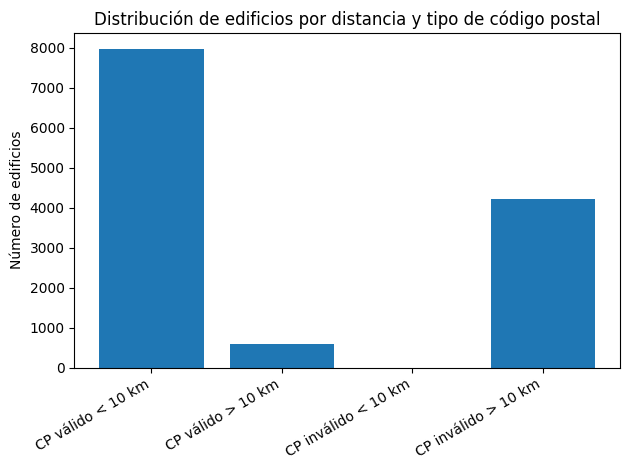

In [ ]:
import matplotlib.pyplot as plt

# Conteos directos desde df (más robusto)
cp_valido_menor_10   = df[(df["tipo_cp"] == "CP válido") & (df["distancia_km"] < 10)]
cp_valido_mayor_10   = df[(df["tipo_cp"] == "CP válido") & (df["distancia_km"] > 10)]
cp_invalido_menor_10 = df[(df["tipo_cp"] == "CP inválido (0,0)") & (df["distancia_km"] < 10)]
cp_invalido_mayor_10 = df[(df["tipo_cp"] == "CP inválido (0,0)") & (df["distancia_km"] > 10)]

labels = [
    "CP válido < 10 km",
    "CP válido > 10 km",
    "CP inválido < 10 km",
    "CP inválido > 10 km"
]

values = [
    len(cp_valido_menor_10),
    len(cp_valido_mayor_10),
    len(cp_invalido_menor_10),
    len(cp_invalido_mayor_10)
]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Número de edificios")
plt.title("Distribución de edificios por distancia y tipo de código postal")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
